# Appliances Energy Prediction

In this project I predict the energy used by the appliances of a low-energy house (`Appliances`,
measured in Wh every 10 minutes). The predictors are temperature and humidity sensors from different
rooms, outdoor weather measurements, and some time information that I extract from the date.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Exploratory Data Analysis (EDA)

The dataset has 19735 rows and 29 columns. The column types are one object (the
date) and the rest are numbers. There are no missing values.

In [2]:
energy = pd.read_csv("energydata_complete.csv")
energy.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
print(energy.shape)
print(energy.dtypes)
print("Missing values:", energy.isnull().sum().sum())

(19735, 29)
date            object
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object
Missing values: 0


In [4]:
energy.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


The histogram shows that the target is right-skewed: most of the time the house uses
little energy (around 50-60 Wh) and only sometimes there are big peaks. The boxplot confirms this,
the median is low and there are many high points on the right side that look like outliers.

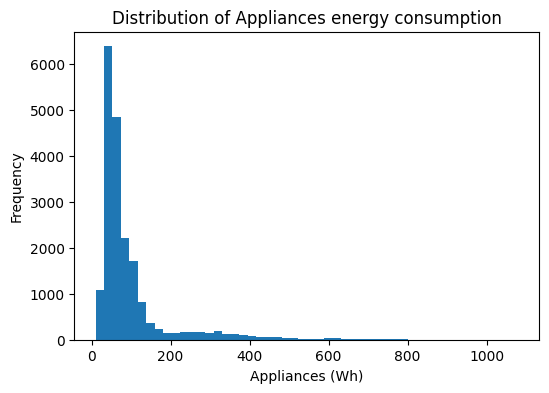

In [5]:
plt.figure(figsize=(6, 4))
plt.hist(energy["Appliances"], bins=50)
plt.xlabel("Appliances (Wh)")
plt.ylabel("Frequency")
plt.title("Distribution of Appliances energy consumption")
plt.show()

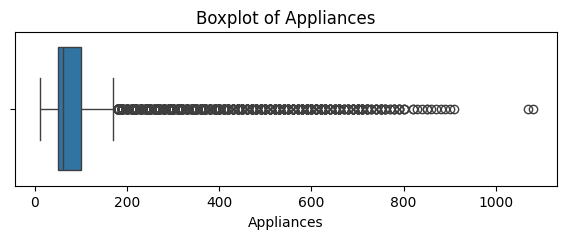

In [6]:
plt.figure(figsize=(7, 2))
sns.boxplot(x=energy["Appliances"])
plt.title("Boxplot of Appliances")
plt.show()

### • Exploring relationships between key predictors and the target using scatter plots and correlations.
I looked at the correlation between the features and the target. All the correlations are
weak (most of them are between -0.15 and +0.20), the strongest is `lights` with about 0.20. This
already tells me that no single feature has a strong straight-line relationship with the target, so a
linear model will probably not be enough.

The features that I expect to be nonlinear are:
- Hour of the day / occupancy 
- Temperature and humidity when it is too cold or too hot people use more
  energy for heating/cooling.

In [7]:
# correlation of every feature with the target
corr_with_target = energy.corr(numeric_only=True)["Appliances"].sort_values(ascending=False)
print(corr_with_target)

Appliances     1.000000
lights         0.197278
T2             0.120073
T6             0.117638
T_out          0.099155
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
T1             0.055447
T4             0.040281
T8             0.039572
RH_3           0.036292
T7             0.025801
T5             0.019760
RH_4           0.016965
Tdewpoint      0.015353
T9             0.010010
RH_5           0.006955
Visibility     0.000230
rv1           -0.011145
rv2           -0.011145
Press_mm_hg   -0.034885
RH_9          -0.051462
RH_7          -0.055642
RH_2          -0.060465
RH_6          -0.083178
RH_8          -0.094039
RH_out        -0.152282
Name: Appliances, dtype: float64


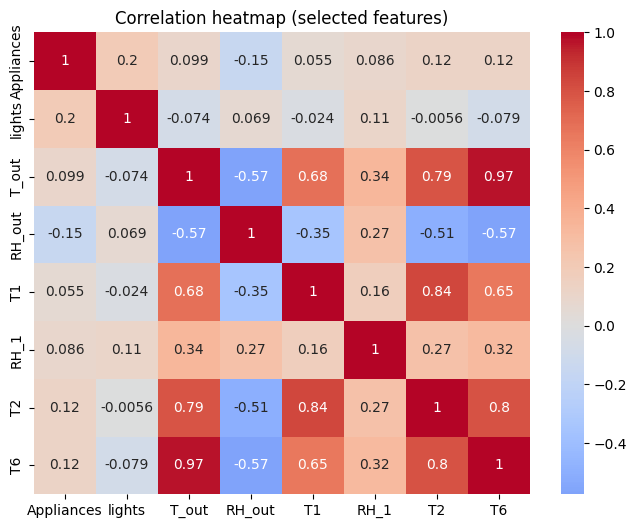

In [8]:
# heatmap on a few selected columns (the full 28x28 matrix is too crowded)
cols = ["Appliances", "lights", "T_out", "RH_out", "T1", "RH_1", "T2", "T6"]
plt.figure(figsize=(8, 6))
sns.heatmap(energy[cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation heatmap (selected features)")
plt.show()

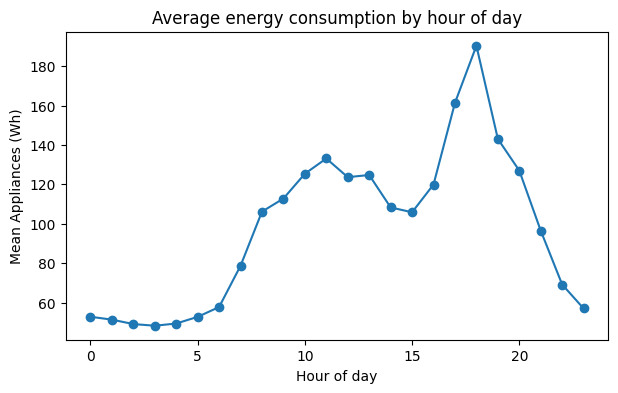

In [9]:
# how the mean consumption changes during the day -> shows the nonlinear time pattern
energy["date"] = pd.to_datetime(energy["date"])
mean_by_hour = energy.groupby(energy["date"].dt.hour)["Appliances"].mean()

plt.figure(figsize=(7, 4))
mean_by_hour.plot(marker="o")
plt.xlabel("Hour of day")
plt.ylabel("Mean Appliances (Wh)")
plt.title("Average energy consumption by hour of day")
plt.show()

# 2. Data Preprocessing

### Missing values
As shown in the EDA there are no missing values, so I do not need to do any imputation or
remove any row.

In [10]:
energy.isnull().sum().sum()

np.int64(0)

### Outliers
The boxplot showed a lot of high values. I checked how many points are above the IQR
upper limit (Q3 + 1.5*IQR). It is about 10% of the data. I decided to keep these outliers, because
they are not measurement errors, they are real moments when the house consumes a lot of energy (for
example cooking or many appliances on at the same time). These are exactly the cases I want to
predict, so removing them would hide the hardest part of the problem.

In [11]:
Q1 = energy["Appliances"].quantile(0.25)
Q3 = energy["Appliances"].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
n_out = (energy["Appliances"] > upper).sum()
print("Upper IQR limit:", round(upper, 1), "Wh")
print("Outliers above it:", n_out, "(", round(100 * n_out / len(energy), 1), "% )")

Upper IQR limit: 175.0 Wh
Outliers above it: 2138 ( 10.8 % )


### Removing the random columns
The columns `rv1` and `rv2` are random variables that were added to the dataset on
purpose. Their correlation with the target is almost zero and they have no physical meaning, so I
remove them. Keeping them would only add noise.

In [12]:
energy = energy.drop(columns=["rv1", "rv2"])

### Feature engineering (time features)
Energy consumption clearly depends on the time, so from the `date` column I create a few
simple time features: the hour, the day of the week, a weekend flag and the month.
After that I drop the `date` column because the models only work with numbers.

In [13]:
energy["hour"] = energy["date"].dt.hour
energy["day_of_week"] = energy["date"].dt.dayofweek      # 0 = Monday
energy["is_weekend"] = (energy["day_of_week"] >= 5).astype(int)
energy["month"] = energy["date"].dt.month
energy = energy.drop(columns=["date"])

y = energy["Appliances"]
X = energy.drop(columns=["Appliances"])
print("Number of features:", X.shape[1])
print(list(X.columns))

Number of features: 29
['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'day_of_week', 'is_weekend', 'month']


### Feature scaling
Not all models need scaling.
- Linear Regression and Polynomial Regression are sensitive to the scale of the features (the
  Ridge penalty depends on the size of the coefficients), so for these I use StandardScaler
  (z-score). I put the scaler inside a `Pipeline` so it is fitted only on the training data and there
  is no information leakage.
- Decision Tree and Random Fores split the data on thresholds and do not care about the scale,
  so for them I do not scale.

# 3. Train/Test Split & Cross-Validation
I split the data into 80% training and 20% test with a fixed `random_state` so the
result is reproducible. The test set is only used at the end to measure how well the models
generalize. For the hyperparameter tuning I use 5-fold cross-validation inside the training set,
because using cross-validation gives a more stable estimate than a single split, and it is important
to validate in a consistent way so that the comparison between models is fair.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (15788, 29)  Test: (3947, 29)


# 4. Model Development
I train one baseline (Linear Regression), two nonlinear models (Polynomial Regression and Decision
Tree) and one ensemble model (Random Forest). For the models that have hyperparameters I use a small
`GridSearchCV` (a few configurations) with 5-fold cross-validation. I save all the results in a list
to compare them at the end.

In [15]:
results = []

def evaluate(name, model):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    r2_test = r2_score(y_test, pred_test)
    r2_train = r2_score(y_train, pred_train)
    print(f"{name}:  MAE={mae:.2f}  RMSE={rmse:.2f}  R2_test={r2_test:.3f}  R2_train={r2_train:.3f}")
    results.append({"Model": name, "MAE": mae, "RMSE": rmse,
                    "R2_train": r2_train, "R2_test": r2_test})

### Model 1 - Linear Regression (baseline)
This is the baseline. Linear Regression has no hyperparameters to tune (if I added a
penalty it would become Ridge/Lasso), so I just fit it. It will tell me the lower bound and how much
the nonlinear models improve.

In [16]:
linear = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
linear.fit(X_train, y_train)
evaluate("Linear Regression", linear)

Linear Regression:  MAE=52.55  RMSE=91.07  R2_test=0.171  R2_train=0.169


### Model 2 — Polynomial Regression (degree 2) + Ridge
Polynomial features add the squared terms and the products between features, so a linear
model can now fit curves and interactions instead of only straight lines. With degree 2 the number of
features becomes large, so I add **Ridge** regularization to avoid overfitting, and I tune the
strength `alpha`.

In [17]:
poly = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("ridge", Ridge())
])
poly_grid = {"ridge__alpha": [1.0, 10.0, 100.0]}
poly_cv = GridSearchCV(poly, poly_grid, cv=5, scoring="r2", n_jobs=-1)
poly_cv.fit(X_train, y_train)
print("Best alpha:", poly_cv.best_params_)
evaluate("Polynomial (deg 2)", poly_cv.best_estimator_)

Best alpha: {'ridge__alpha': 1.0}


Polynomial (deg 2):  MAE=48.58  RMSE=82.70  R2_test=0.317  R2_train=0.368


### Model 3 — Decision Tree
A decision tree splits the data into regions, so it can model thresholds and nonlinear
patterns (for example "if it is evening and lights are on, energy is high"). The most important
hyperparameter is the depth of the tree: if it is too small the tree underfits, if it is too big it
overfits. I tune `max_depth` and `min_samples_leaf`.

In [18]:
tree = DecisionTreeRegressor(random_state=42)
tree_grid = {"max_depth": [5, 10, 15, 20], "min_samples_leaf": [10]}
tree_cv = GridSearchCV(tree, tree_grid, cv=5, scoring="r2", n_jobs=-1)
tree_cv.fit(X_train, y_train)
print("Best params:", tree_cv.best_params_)
evaluate("Decision Tree", tree_cv.best_estimator_)

Best params: {'max_depth': 20, 'min_samples_leaf': 10}
Decision Tree:  MAE=38.79  RMSE=81.43  R2_test=0.337  R2_train=0.633


### Model 4 — Random Forest (ensemble)
A random forest trains many decision trees on random subsets of the data and averages
their predictions. A single tree has high variance (it changes a lot with the data), but averaging
many trees **reduces the variance** and usually gives a better and more stable result. This is why I
expect the ensemble to be the best model. I tune the number of trees, the depth and the minimum leaf
size (I keep the grid small so the training does not take too long).

In [19]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_grid = {"n_estimators": [100, 200], "max_depth": [10, 20], "min_samples_leaf": [2]}
rf_cv = GridSearchCV(rf, rf_grid, cv=5, scoring="r2", n_jobs=1)
rf_cv.fit(X_train, y_train)
print("Best params:", rf_cv.best_params_)
evaluate("Random Forest", rf_cv.best_estimator_)

Best params: {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 200}


Random Forest:  MAE=31.88  RMSE=67.33  R2_test=0.547  R2_train=0.873


# 5. Model Evaluation & Comparison

### Comparison table
The table below shows the MAE, RMSE and R² of every model on the test set, plus the R² on
the training set so I can see overfitting.

In [20]:
results_df = pd.DataFrame(results).sort_values("R2_test", ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,MAE,RMSE,R2_train,R2_test
0,Random Forest,31.878,67.334,0.873,0.547
1,Decision Tree,38.790,81.431,0.633,0.337
2,Polynomial (deg 2),48.579,82.703,0.368,0.317
3,Linear Regression,52.551,91.070,0.169,0.171


### Overfitting vs underfitting

- **Linear Regression** has a low R² on both train and test (around 0.20), which means it
  **underfits**: the model is too simple for this nonlinear problem.
- **Random Forest** has a much higher R² on the train set than on the test set. This means it has
  some **overfitting** (it can almost memorize the training data), but thanks to the averaging of the
  trees it still has the **best test score**, so it is the model that generalizes best.

So the comparison of train and test errors shows the typical trade-off: too simple model = underfit,
very flexible model = some overfit but better test performance.

### Residual plot of the best model
I plot the predicted vs actual values and the residuals for the best model. The points
follow the diagonal for low/medium consumption, but for the high values the model predicts too low
(the residuals get bigger). This is the heteroscedasticity I expected because of the skewed target:
the model is good for normal consumption and struggles with the rare big peaks.

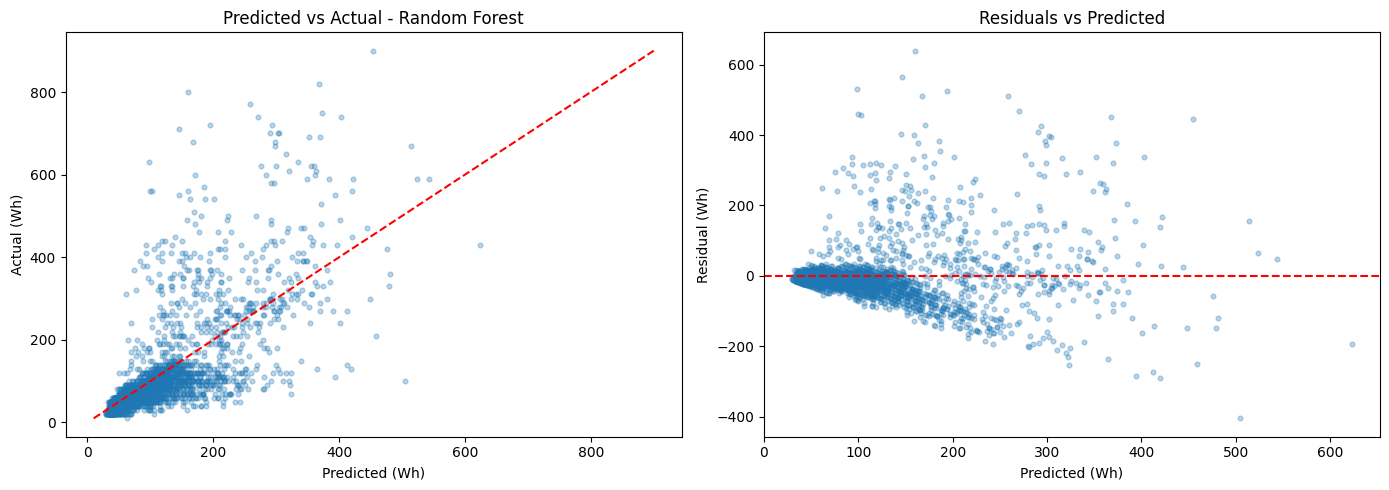

Best model: Random Forest


In [21]:
best_name = results_df.iloc[0]["Model"]
best_model = {"Linear Regression": linear,
              "Polynomial (deg 2)": poly_cv.best_estimator_,
              "Decision Tree": tree_cv.best_estimator_,
              "Random Forest": rf_cv.best_estimator_}[best_name]

pred_test = best_model.predict(X_test)
residuals = y_test - pred_test

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(pred_test, y_test, alpha=0.3, s=12)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
ax[0].set_xlabel("Predicted (Wh)")
ax[0].set_ylabel("Actual (Wh)")
ax[0].set_title("Predicted vs Actual - " + best_name)

ax[1].scatter(pred_test, residuals, alpha=0.3, s=12)
ax[1].axhline(0, color="r", linestyle="--")
ax[1].set_xlabel("Predicted (Wh)")
ax[1].set_ylabel("Residual (Wh)")
ax[1].set_title("Residuals vs Predicted")
plt.tight_layout()
plt.show()
print("Best model:", best_name)

# 6. Error Analysis & Interpretation

### Feature importance (Random Forest)
**Answer:** For the random forest I look at the feature importances to see which variables are the
most useful for the prediction. The most important feature **by far is the hour**, followed by several
**temperature and humidity** sensors. This makes sense with the domain: appliance use depends mainly
on when people are active in the house and on the indoor conditions. Note that `lights` had the
strongest *linear correlation* with the target (about 0.2) but only a moderate importance here,
because the hour feature already captures most of the time-of-day signal.

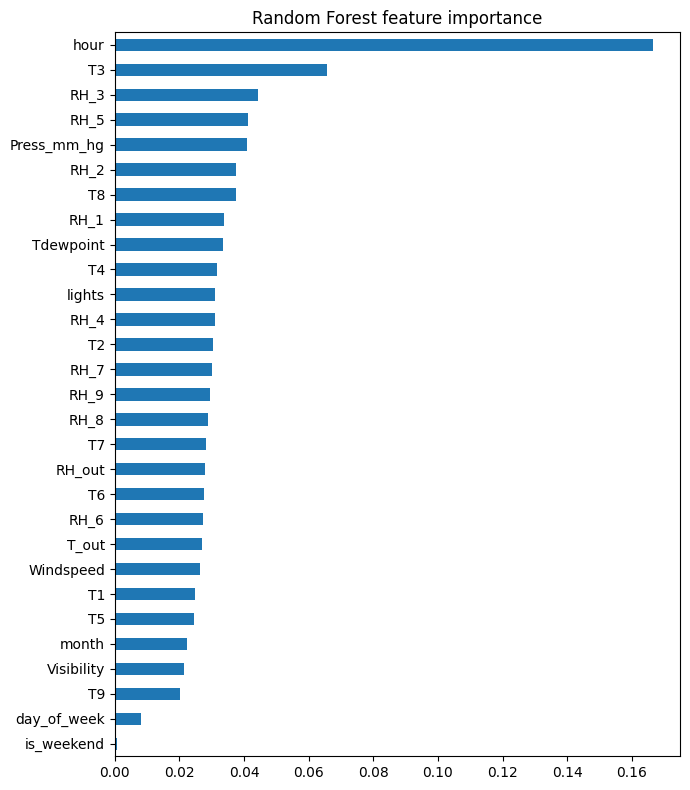

In [22]:
importances = pd.Series(rf_cv.best_estimator_.feature_importances_,
                        index=X.columns).sort_values()
plt.figure(figsize=(7, 8))
importances.plot(kind="barh")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()

### Linear model coefficients
For the linear model I can look at the coefficients (the features are standardized, so the
size of the coefficient shows how strong the effect is). The signs and sizes are consistent with the
random forest importances (for example `lights` and the hour have a clear effect), but the linear
model still cannot reach the same accuracy because it only captures straight-line effects.

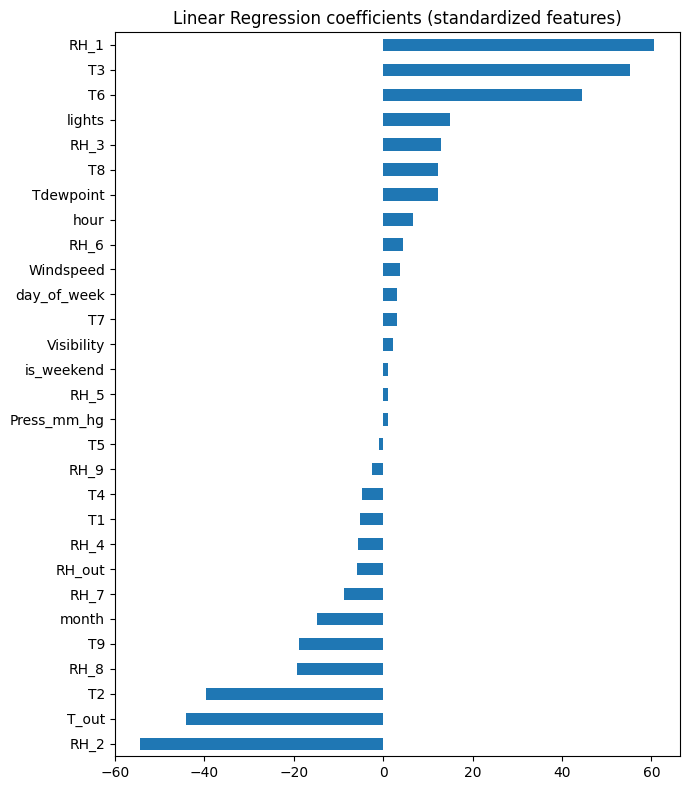

In [23]:
coef = pd.Series(linear.named_steps["model"].coef_, index=X.columns).sort_values()
plt.figure(figsize=(7, 8))
coef.plot(kind="barh")
plt.title("Linear Regression coefficients (standardized features)")
plt.tight_layout()
plt.show()

# 7. Conclusion

The **Random Forest** was the best model. It clearly beat the
Linear Regression baseline (about R² 0.55 vs 0.20). This confirms what I expected from the EDA: the
relationship between the sensors and the energy use is nonlinear, so the models that can capture
nonlinearity and interactions (the trees, and especially the ensemble that averages many trees) work
much better than the linear model. The Polynomial Regression was in the middle: it improved on the
linear model by adding curvature, but it was still worse than the trees.




# References
- Candanedo, L. M., Feldmann, A., & Degemmis, D. (2017). *Data driven prediction models of energy use
  of appliances in a low-energy house.* Energy and Buildings, 145, 13-25.
- UCI Machine Learning Repository — Appliances Energy Prediction (dataset 374).
- Scikit-learn documentation (https://scikit-learn.org).
- Alex the Analyst: https://www.youtube.com/@AlexTheAnalyst

